# Muse EEG Blink Detector

Train a classifier to detect blinks from raw Muse 2 EEG data.

## Cell 1 — Load and Inspect Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")

CHANNELS = ["TP9", "AF7", "AF8", "TP10"]
FS = 256

df = pd.read_csv("blink_data.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nLabel distribution:\n{df['label'].value_counts().to_string()}")

duration = df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]
print(f"\nDuration: {duration:.1f} seconds")

# Count blink events (contiguous label=1 regions)
blink_changes = np.diff(df["label"].values, prepend=0)
n_blink_events = (blink_changes == 1).sum()
print(f"Blink events: {n_blink_events}")
print(f"Blink samples: {(df['label'] == 1).sum()}")
print(f"Rest samples: {(df['label'] == 0).sum()}")

Shape: (11511, 6)
Columns: ['timestamp', 'TP9', 'AF7', 'AF8', 'TP10', 'label']

Dtypes:
timestamp    float64
TP9          float64
AF7          float64
AF8          float64
TP10         float64
label          int64
dtype: object

Label distribution:
label
0    9873
1    1638

Duration: 59.9 seconds
Blink events: 17
Blink samples: 1638
Rest samples: 9873


## Cell 2 — Raw Signal Visualization

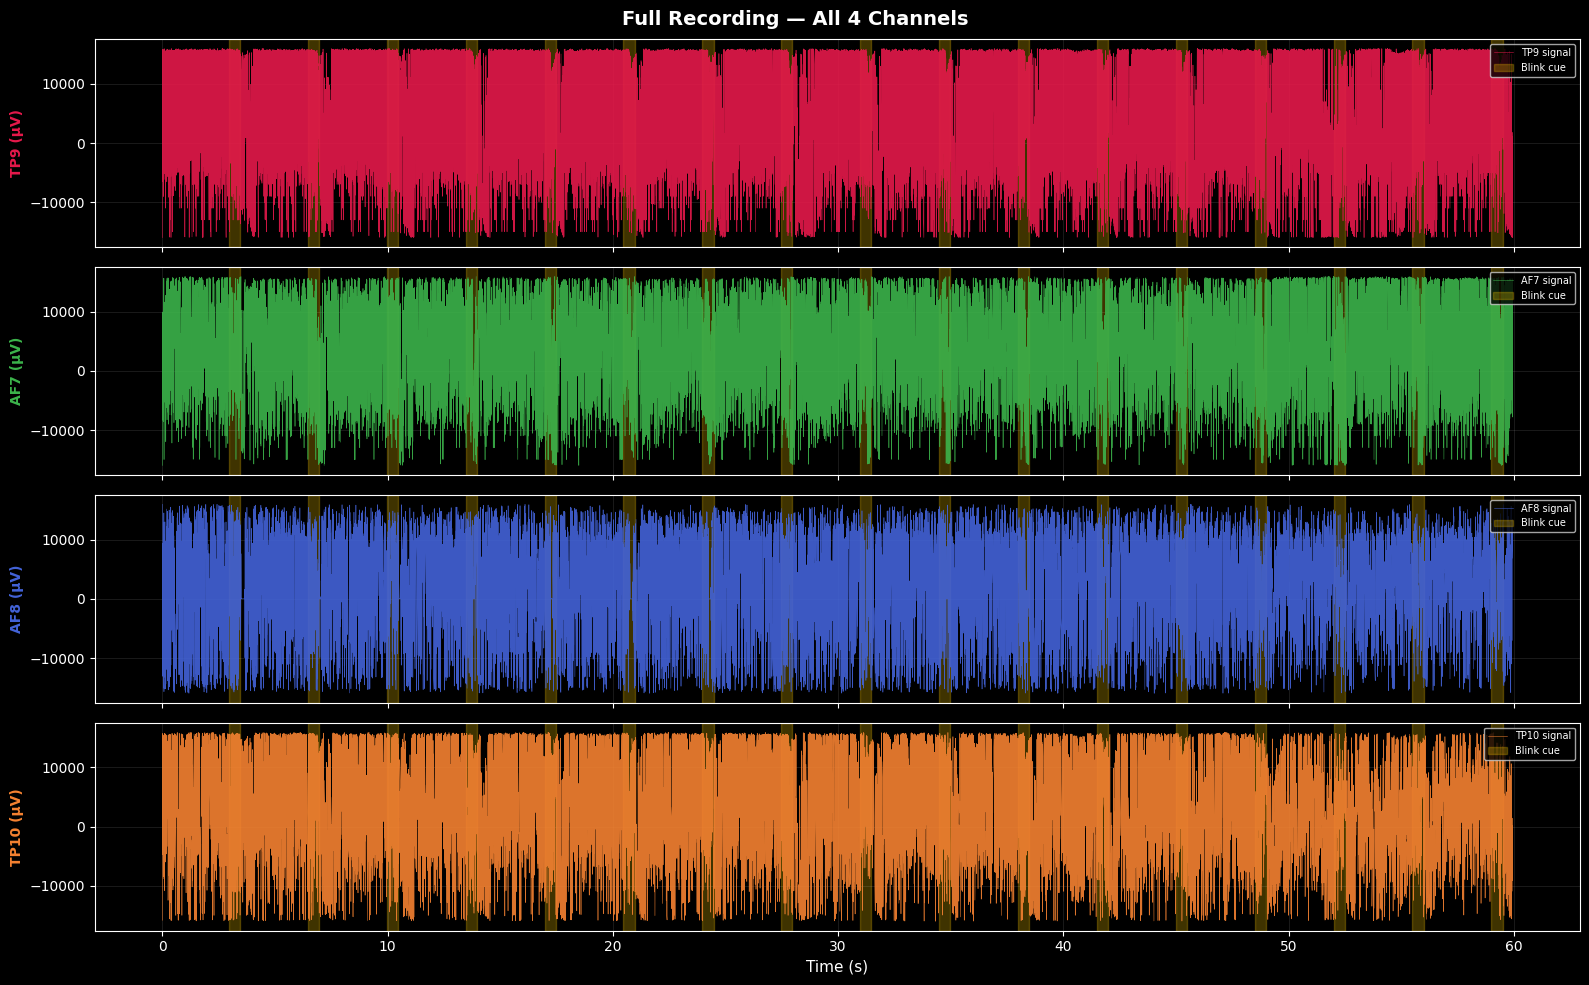

In [2]:
t = df["timestamp"].values
labels = df["label"].values
colors = {"TP9": "#e6194b", "AF7": "#3cb44b", "AF8": "#4363d8", "TP10": "#f58231"}

# Find blink window edges
blink_changes = np.diff(labels, prepend=0)
blink_starts = t[blink_changes == 1]
blink_ends_mask = blink_changes == -1
blink_ends = t[blink_ends_mask] if blink_ends_mask.any() else np.array([])
if len(blink_starts) > len(blink_ends):
    blink_ends = np.append(blink_ends, t[-1])

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle("Full Recording — All 4 Channels", fontsize=14, fontweight="bold")

for i, ch in enumerate(CHANNELS):
    ax = axes[i]
    ax.plot(t, df[ch].values, color=colors[ch], linewidth=0.4, alpha=0.9, label=f"{ch} signal")
    for idx, (s, e) in enumerate(zip(blink_starts, blink_ends)):
        ax.axvspan(s, e, alpha=0.25, color="#ffcc00", label="Blink cue" if idx == 0 else None)
    ax.set_ylabel(f"{ch} (µV)", fontsize=10, fontweight="bold", color=colors[ch])
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.1)

axes[-1].set_xlabel("Time (s)", fontsize=11)
plt.tight_layout()
plt.show()

## Cell 3 — Zoom Into Individual Blinks

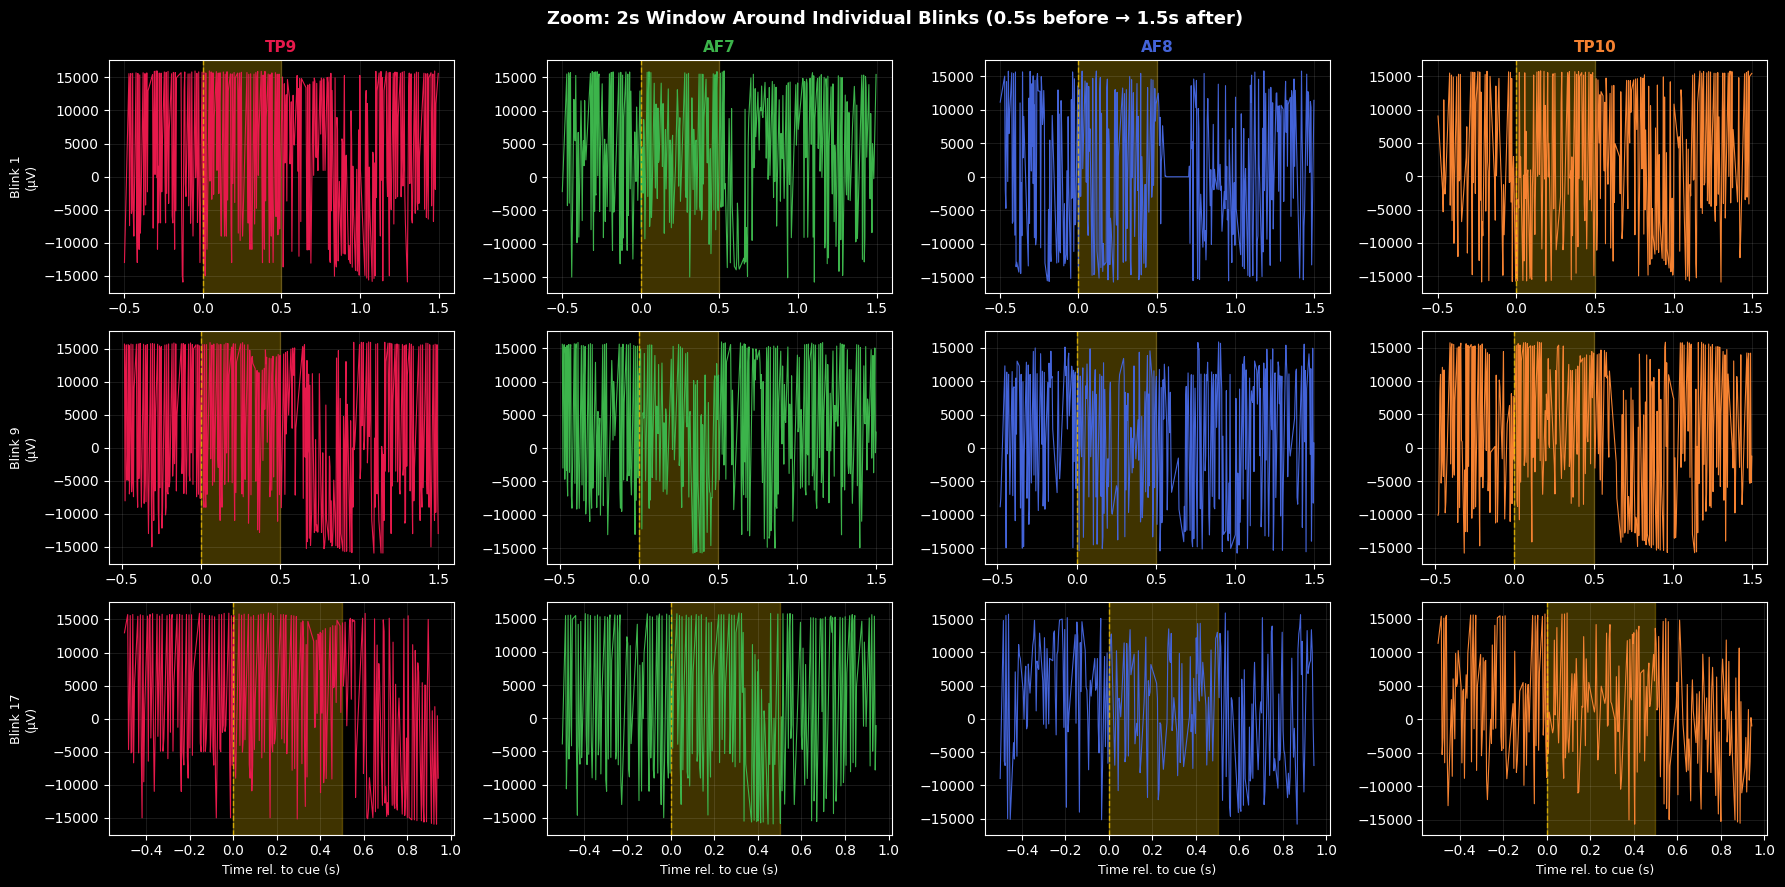

In [6]:
# Pick 3 evenly spaced blink events
pick_indices = np.linspace(0, len(blink_starts) - 1, 3, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(18, 9), sharex="row")
fig.suptitle("Zoom: 2s Window Around Individual Blinks (0.5s before → 1.5s after)", fontsize=13, fontweight="bold")

for row, bi in enumerate(pick_indices):
    cue_t = blink_starts[bi]
    win_start = cue_t - 0.5
    win_end = cue_t + 1.5
    mask = (t >= win_start) & (t <= win_end)
    t_win = t[mask] - cue_t  # center on cue

    for col, ch in enumerate(CHANNELS):
        ax = axes[row, col]
        sig = df[ch].values[mask]
        ax.plot(t_win, sig, color=colors[ch], linewidth=0.8)
        ax.axvspan(0, 0.5, alpha=0.25, color="#ffcc00")
        ax.axvline(0, color="#ffcc00", linewidth=1, linestyle="--", alpha=0.7)
        ax.grid(True, alpha=0.1)
        if row == 0:
            ax.set_title(ch, fontsize=11, fontweight="bold", color=colors[ch])
        if col == 0:
            ax.set_ylabel(f"Blink {bi+1}\n(µV)", fontsize=9)
        if row == 2:
            ax.set_xlabel("Time rel. to cue (s)", fontsize=9)

plt.tight_layout()
plt.show()

## Cell 4 — Feature Engineering

In [7]:
from scipy.signal import welch

WINDOW_SAMPLES = 128  # 0.5s at 256Hz

def band_power(signal, fs, fmin, fmax):
    """Compute power in a frequency band using Welch."""
    nperseg = min(len(signal), 128)
    if nperseg < 4:
        return 0.0
    f, pxx = welch(signal, fs=fs, nperseg=nperseg)
    mask = (f >= fmin) & (f <= fmax)
    return np.trapezoid(pxx[mask], f[mask]) if mask.any() else 0.0

def extract_features(window_df):
    """Extract features from a 0.5s window for all channels."""
    feats = {}
    for ch in CHANNELS:
        sig = window_df[ch].values
        feats[f"{ch}_mean_abs"] = np.mean(np.abs(sig))
        feats[f"{ch}_std"] = np.std(sig)
        feats[f"{ch}_ptp"] = np.ptp(sig)
        feats[f"{ch}_power_0.5_5"] = band_power(sig, FS, 0.5, 5.0)
        feats[f"{ch}_power_8_12"] = band_power(sig, FS, 8.0, 12.0)
    return feats

# Split into non-overlapping 0.5s windows
n_samples = len(df)
feature_rows = []
window_labels = []

for start in range(0, n_samples - WINDOW_SAMPLES + 1, WINDOW_SAMPLES):
    end = start + WINDOW_SAMPLES
    window = df.iloc[start:end]
    feats = extract_features(window)
    feature_rows.append(feats)
    # Label: 1 if any sample in window is blink
    window_labels.append(1 if window["label"].sum() > 0 else 0)

feat_df = pd.DataFrame(feature_rows)
feat_df["label"] = window_labels

print(f"Feature matrix shape: {feat_df.shape}")
print(f"Features per window: {feat_df.shape[1] - 1}")
print(f"\nLabel distribution:")
print(f"  Rest (0):  {(feat_df['label'] == 0).sum()}")
print(f"  Blink (1): {(feat_df['label'] == 1).sum()}")
print(f"\nFeature names: {list(feat_df.columns[:-1])}")
feat_df.head()

Feature matrix shape: (89, 21)
Features per window: 20

Label distribution:
  Rest (0):  59
  Blink (1): 30

Feature names: ['TP9_mean_abs', 'TP9_std', 'TP9_ptp', 'TP9_power_0.5_5', 'TP9_power_8_12', 'AF7_mean_abs', 'AF7_std', 'AF7_ptp', 'AF7_power_0.5_5', 'AF7_power_8_12', 'AF8_mean_abs', 'AF8_std', 'AF8_ptp', 'AF8_power_0.5_5', 'AF8_power_8_12', 'TP10_mean_abs', 'TP10_std', 'TP10_ptp', 'TP10_power_0.5_5', 'TP10_power_8_12']


,TP9_mean_abs,TP9_std,TP9_ptp,TP9_power_0.5_5,TP9_power_8_12,AF7_mean_abs,AF7_std,AF7_ptp,AF7_power_0.5_5,AF7_power_8_12,...,AF8_std,AF8_ptp,AF8_power_0.5_5,AF8_power_8_12,TP10_mean_abs,TP10_std,TP10_ptp,TP10_power_0.5_5,TP10_power_8_12,label
0,9067.638405,10064.617504,31983.8868,1.022954e+06,1.551483e+06,7957.447287,8766.709239,31824.7669,1.095127e+05,8.506181e+05,...,10865.244612,31767.0009,4.944813e+06,5.920882e+06,8463.177202,9744.405503,31612.4352,1.321937e+06,4.534747e+06,0
1,9055.198680,9784.349064,31945.8007,2.669393e+05,2.109922e+06,8099.110483,8635.767596,27966.3896,1.784322e+05,1.236242e+06,...,10877.805987,31756.0108,4.380765e+05,5.400203e+05,8368.272002,9797.153452,31673.7785,1.834408e+06,1.224502e+06,0
2,8729.721079,9933.523298,31913.5742,8.146189e+05,1.082427e+06,7875.868211,8345.315633,30835.1995,3.368549e+05,8.354167e+05,...,11221.439337,31800.8968,1.645119e+06,3.652583e+06,8574.144916,9986.043345,31743.8160,6.374356e+05,9.264603e+06,0
3,9819.984441,10824.942689,31905.7617,3.229375e+05,1.464969e+06,8085.440522,8677.778352,30889.3931,1.322232e+06,3.708817e+06,...,10757.209575,31341.3857,2.660830e+06,1.166019e+06,8143.538249,8991.526716,31591.8165,9.618517e+05,1.447159e+06,0
4,9697.776800,10527.194506,31976.5625,5.877791e+05,4.899144e+06,7747.370227,8463.645409,30837.7045,1.909069e+05,4.525364e+05,...,11258.564926,31550.8888,3.259921e+06,5.223932e+05,8401.383987,10299.190227,31693.9143,3.989710e+06,1.580372e+06,1


## Cell 5 — Feature Exploration

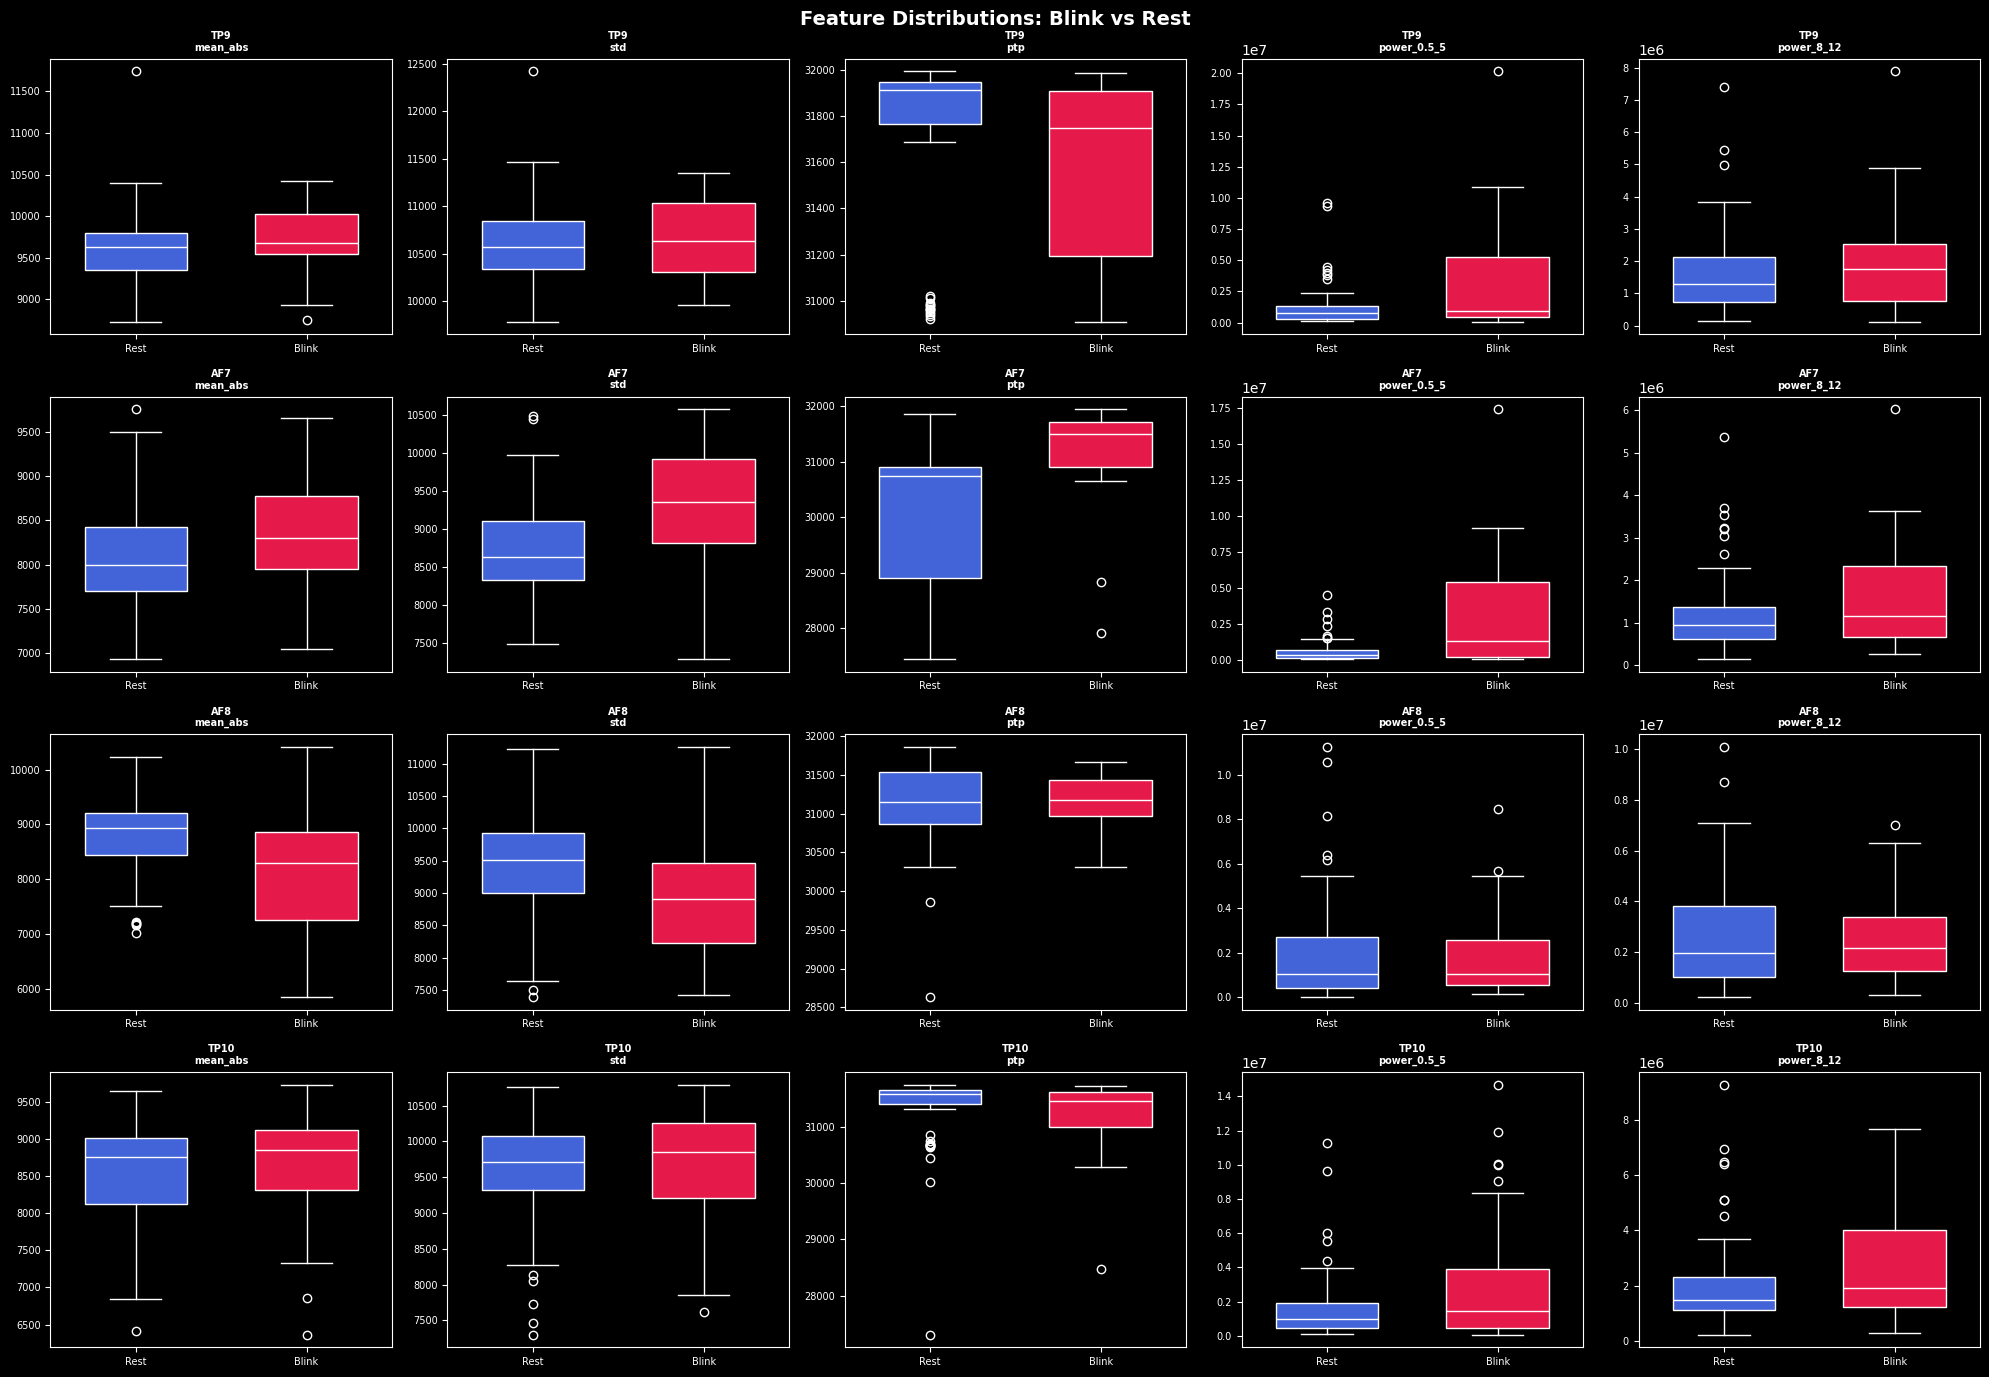

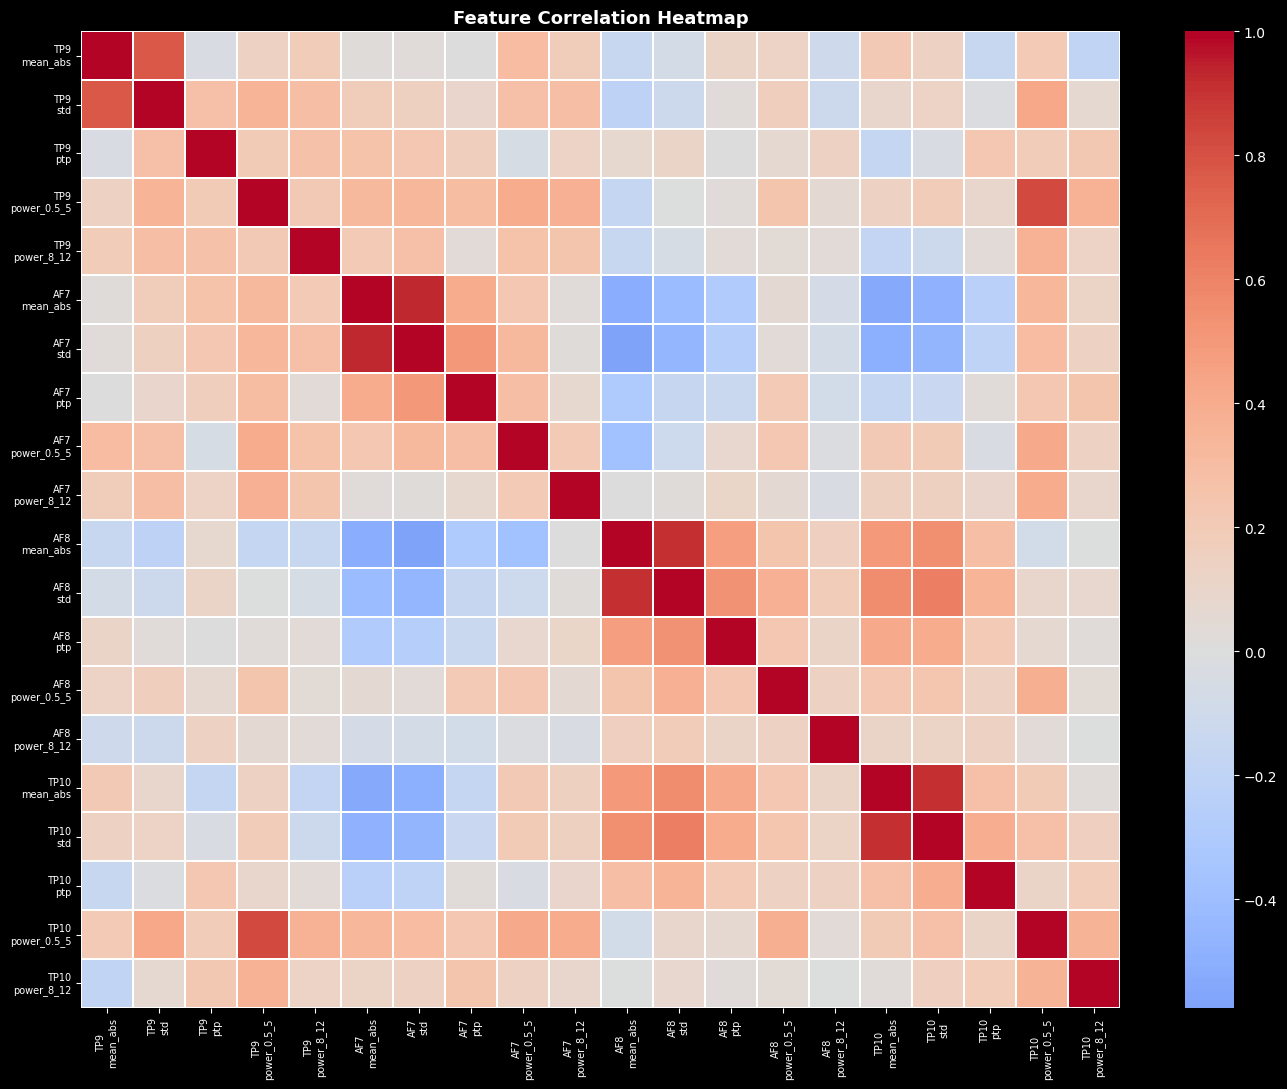

Top features by separability (|mean_diff| / std):
  AF7_power_0.5_5                0.932
  AF7_ptp                        0.845
  AF8_mean_abs                   0.720
  AF7_std                        0.695
  TP9_power_0.5_5                0.652
  TP10_power_0.5_5               0.522
  AF8_std                        0.512
  AF7_mean_abs                   0.390
  AF7_power_8_12                 0.335
  TP9_ptp                        0.292


In [8]:
import seaborn as sns

feature_cols = [c for c in feat_df.columns if c != "label"]

# --- Box plots: blink vs rest for each feature ---
n_feats = len(feature_cols)
n_cols = 5
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten()
fig.suptitle("Feature Distributions: Blink vs Rest", fontsize=14, fontweight="bold")

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    data_rest = feat_df.loc[feat_df["label"] == 0, feat]
    data_blink = feat_df.loc[feat_df["label"] == 1, feat]
    bp = ax.boxplot([data_rest, data_blink], labels=["Rest", "Blink"],
                    patch_artist=True, widths=0.6)
    bp["boxes"][0].set_facecolor("#4363d8")
    bp["boxes"][1].set_facecolor("#e6194b")
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("white")
    ax.set_title(feat.replace("_", "\n", 1), fontsize=7, fontweight="bold")
    ax.tick_params(labelsize=7)

for i in range(n_feats, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(14, 11))
corr = feat_df[feature_cols].corr()
sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, annot=False,
            xticklabels=[c.replace("_", "\n", 1) for c in feature_cols],
            yticklabels=[c.replace("_", "\n", 1) for c in feature_cols],
            linewidths=0.3)
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

# --- Most separating features (by absolute difference in means, normalized) ---
separability = {}
for feat in feature_cols:
    rest_mean = feat_df.loc[feat_df["label"] == 0, feat].mean()
    blink_mean = feat_df.loc[feat_df["label"] == 1, feat].mean()
    pooled_std = feat_df[feat].std()
    if pooled_std > 0:
        separability[feat] = abs(blink_mean - rest_mean) / pooled_std
    else:
        separability[feat] = 0

sep_sorted = sorted(separability.items(), key=lambda x: x[1], reverse=True)
print("Top features by separability (|mean_diff| / std):")
for feat, score in sep_sorted[:10]:
    print(f"  {feat:30s} {score:.3f}")

## Cell 6 — Train Classifier

Random Forest              acc=0.556  prec=0.250  rec=0.167  f1=0.200
SVM                        acc=0.667  prec=0.500  rec=0.167  f1=0.250
Logistic Regression        acc=0.722  prec=0.571  rec=0.667  f1=0.615

Best model: Logistic Regression (F1=0.615)


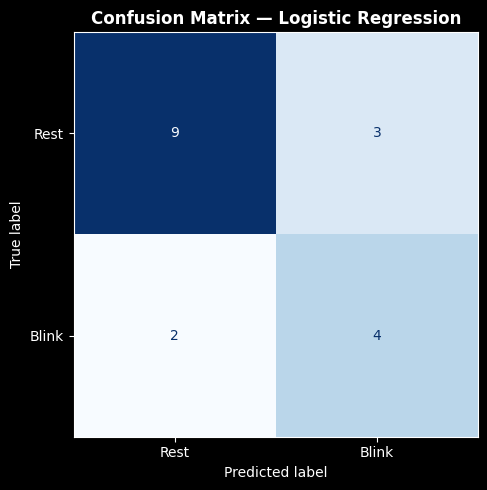

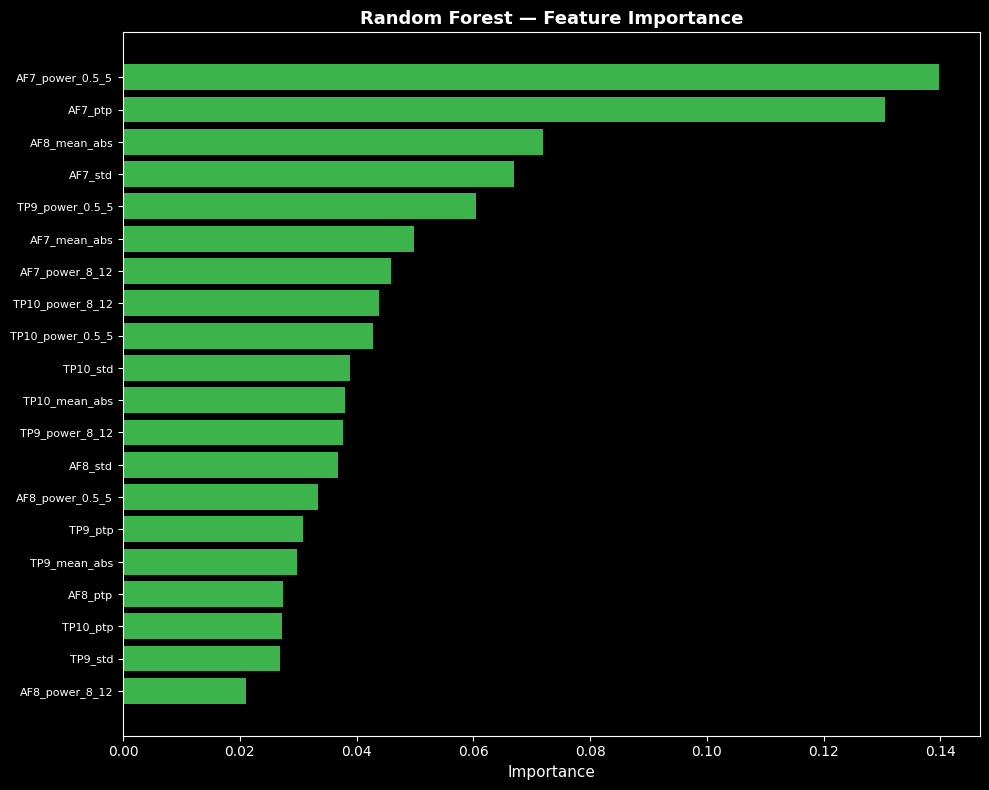

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

X = feat_df[feature_cols].values
y = feat_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
}

results = {}
for name, model in models.items():
    # SVM and LR use scaled data
    Xtr = X_train_s if name != "Random Forest" else X_train
    Xte = X_test_s if name != "Random Forest" else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "y_pred": y_pred,
    }
    print(f"{name:25s}  acc={results[name]['accuracy']:.3f}  prec={results[name]['precision']:.3f}  "
          f"rec={results[name]['recall']:.3f}  f1={results[name]['f1']:.3f}")

# Best model by F1
best_name = max(results, key=lambda k: results[k]["f1"])
print(f"\nBest model: {best_name} (F1={results[best_name]['f1']:.3f})")

# Confusion matrix for best model
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Rest", "Blink"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Feature importance (Random Forest)
rf = models["Random Forest"]
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(sorted_idx)), importances[sorted_idx], color="#3cb44b")
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx], fontsize=8)
ax.set_xlabel("Importance", fontsize=11)
ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Cell 7 — ROC Curves

Random Forest              AUC=0.472
SVM                        AUC=0.569
Logistic Regression        AUC=0.597


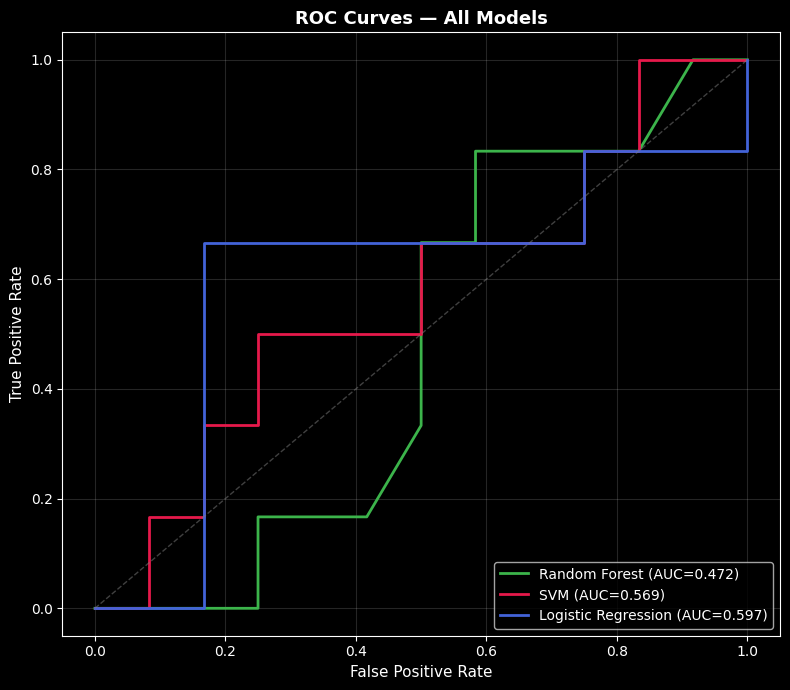

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 7))
roc_colors = {"Random Forest": "#3cb44b", "SVM": "#e6194b", "Logistic Regression": "#4363d8"}

for name, model in models.items():
    Xte = X_test_s if name != "Random Forest" else X_test
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=roc_colors[name], linewidth=2, label=f"{name} (AUC={auc:.3f})")
    print(f"{name:25s}  AUC={auc:.3f}")

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

## Cell 8 — Save Model

In [ ]:
import pickle

# Save the best model + scaler + feature names
best_model = models[best_name]
model_bundle = {
    "model": best_model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "best_name": best_name,
}

with open("blink_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print(f"Model saved to blink_model.pkl")
print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"Best model:    {best_name}")
print(f"Accuracy:      {results[best_name]['accuracy']:.3f}")
print(f"F1 Score:      {results[best_name]['f1']:.3f}")
print(f"Precision:     {results[best_name]['precision']:.3f}")
print(f"Recall:        {results[best_name]['recall']:.3f}")

# Top features
if best_name == "Random Forest":
    imp = best_model.feature_importances_
else:
    imp = np.abs(best_model.coef_[0]) if hasattr(best_model, "coef_") else rf.feature_importances_

top_idx = np.argsort(imp)[::-1][:5]
print(f"\nTop 5 features:")
for i in top_idx:
    print(f"  {feature_cols[i]:30s}  importance={imp[i]:.4f}")

# Channel importance (sum feature importances per channel)
print(f"\nChannel importance:")
for ch in CHANNELS:
    ch_feats = [j for j, f in enumerate(feature_cols) if f.startswith(ch)]
    ch_imp = sum(imp[j] for j in ch_feats)
    bar = "#" * int(ch_imp / max(imp) * 20)
    print(f"  {ch:6s}  {ch_imp:.4f}  {bar}")